# 05a — Model A Training: Lap + Tyre (2019-2024)

Predicts **lap-level position** using 9 features including tyre data.
CV: LeaveOneSeasonOut (test season = 2024).

## 0. Setup

In [1]:
import os
from pathlib import Path

if not (Path.cwd() / "pyproject.toml").exists():
    # We're likely in notebooks/ — go up to repo root
    for p in [Path.cwd().parent, Path.cwd().parent.parent]:
        if (p / "pyproject.toml").exists():
            os.chdir(p)
            break

print(f"Working directory: {Path.cwd()}")

Working directory: /opt/f1-training


In [2]:
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

from f1_predictor.features.splits import ExpandingWindowSplit, LeaveOneSeasonOut
from f1_predictor.data.storage import (
    load_from_gcs_or_local,
    load_training_parquet,
    save_training_parquet,
    save_model_pickle as gcs_save_model_pickle,
    save_notebook,
    sync_training_from_gcs,
)
from f1_predictor.models.gpu import (
    detect_gpu_backend, get_lightgbm_device, get_torch_device, get_xgboost_device,
)

warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

TRAINING_DIR = Path("data/training")
MODEL_DIR = Path("data/raw/model")
TRAINING_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# GPU detection (supports NVIDIA CUDA and AMD ROCm)
GPU_BACKEND, GPU_NAME = detect_gpu_backend()
TORCH_DEVICE = get_torch_device()
print(f"GPU backend: {GPU_BACKEND} ({GPU_NAME})")
print(f"PyTorch device: {TORCH_DEVICE}")

# Deep learning models (PyTorch — works on both CUDA and ROCm via HIP)
DL_AVAILABLE = False
try:
    from f1_predictor.models.architectures import GRU2Layer, FTTransformerWrapper, MLP3Layer
    DL_AVAILABLE = TORCH_DEVICE != "cpu"
    print(f"DL models available: {DL_AVAILABLE}")
except ImportError:
    print("DL models not available (torch/rtdl not installed)")

GPU backend: cuda (NVIDIA L4)
PyTorch device: cuda
DL models available: True


In [3]:
NAN_TOLERANT = {
    "XGBoost", "XGBoost_DART", "XGBoost_Linear",
    "LightGBM", "LightGBM_DART", "LightGBM_GOSS",
    "XGBoost_Conservative", "XGBoost_Deep",
    "LightGBM_Shallow", "LightGBM_Deep",
}

DL_SKIP_OPTUNA = {"GRU_2layer", "FT_Transformer", "MLP_3layer"}


def get_candidates():
    """Return dict of model_name -> model instance. GPU-accelerated where possible."""
    xgb_device = get_xgboost_device(GPU_BACKEND)
    lgb_device = get_lightgbm_device(GPU_BACKEND)

    candidates = {
        # XGBoost variants (GPU on CUDA, CPU on ROCm)
        "XGBoost": xgb.XGBRegressor(
            n_estimators=300, n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "XGBoost_DART": xgb.XGBRegressor(
            n_estimators=300, booster="dart", n_jobs=-1,
            random_state=42, verbosity=0, **xgb_device),
        "XGBoost_Linear": xgb.XGBRegressor(
            n_estimators=300, booster="gblinear", n_jobs=-1,
            random_state=42, verbosity=0, **xgb_device),
        # LightGBM variants (GPU via OpenCL on both CUDA and ROCm)
        "LightGBM": lgb.LGBMRegressor(
            n_estimators=300, n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
        "LightGBM_DART": lgb.LGBMRegressor(
            n_estimators=300, boosting_type="dart", n_jobs=-1,
            random_state=42, verbose=-1, **lgb_device),
        "LightGBM_GOSS": lgb.LGBMRegressor(
            n_estimators=300, boosting_type="goss", n_jobs=-1,
            random_state=42, verbose=-1, **lgb_device),
        # Extra tree-based variants
        "XGBoost_Conservative": xgb.XGBRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "LightGBM_Shallow": lgb.LGBMRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
        "XGBoost_Deep": xgb.XGBRegressor(
            n_estimators=300, max_depth=10, learning_rate=0.1,
            n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "LightGBM_Deep": lgb.LGBMRegressor(
            n_estimators=300, max_depth=10, learning_rate=0.1,
            n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
    }

    # Deep learning candidates (PyTorch — works on both CUDA and ROCm via HIP)
    if DL_AVAILABLE:
        n_feat = len(FEATURE_COLS)
        candidates["GRU_2layer"] = GRU2Layer(input_dim=n_feat)
        candidates["FT_Transformer"] = FTTransformerWrapper(n_features=n_feat)

    print(f"Candidates ({len(candidates)}): {list(candidates.keys())}")
    return candidates


def get_candidates_c():
    """Return dict of candidates for Model C (race-level, includes MLP)."""
    xgb_device = get_xgboost_device(GPU_BACKEND)
    lgb_device = get_lightgbm_device(GPU_BACKEND)

    candidates = {
        "XGBoost": xgb.XGBRegressor(
            n_estimators=300, n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "XGBoost_DART": xgb.XGBRegressor(
            n_estimators=300, booster="dart", n_jobs=-1,
            random_state=42, verbosity=0, **xgb_device),
        "XGBoost_Linear": xgb.XGBRegressor(
            n_estimators=300, booster="gblinear", n_jobs=-1,
            random_state=42, verbosity=0, **xgb_device),
        "LightGBM": lgb.LGBMRegressor(
            n_estimators=300, n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
        "LightGBM_DART": lgb.LGBMRegressor(
            n_estimators=300, boosting_type="dart", n_jobs=-1,
            random_state=42, verbose=-1, **lgb_device),
        "LightGBM_GOSS": lgb.LGBMRegressor(
            n_estimators=300, boosting_type="goss", n_jobs=-1,
            random_state=42, verbose=-1, **lgb_device),
        "XGBoost_Conservative": xgb.XGBRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "LightGBM_Shallow": lgb.LGBMRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
        "XGBoost_Deep": xgb.XGBRegressor(
            n_estimators=300, max_depth=10, learning_rate=0.1,
            n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "LightGBM_Deep": lgb.LGBMRegressor(
            n_estimators=300, max_depth=10, learning_rate=0.1,
            n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
    }

    if DL_AVAILABLE:
        n_feat = len(FEATURE_COLS)
        candidates["MLP_3layer"] = MLP3Layer(input_dim=n_feat)

    print(f"Candidates ({len(candidates)}): {list(candidates.keys())}")
    return candidates


def cv_evaluate(model, X, y, splitter, groups):
    """Evaluate model across CV folds. Returns dict with fold and mean metrics."""
    fold_rmse, fold_mae = [], []
    for train_idx, val_idx in splitter.split(groups):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        import sklearn.base
        m = sklearn.base.clone(model)
        m.fit(X_tr, y_tr)
        preds = m.predict(X_val)
        fold_rmse.append(np.sqrt(mean_squared_error(y_val, preds)))
        fold_mae.append(mean_absolute_error(y_val, preds))
    return {
        "fold_rmse": fold_rmse,
        "fold_mae": fold_mae,
        "mean_rmse": np.mean(fold_rmse),
        "std_rmse": np.std(fold_rmse),
        "mean_mae": np.mean(fold_mae),
    }


def screen_models(candidates, X, y, splitter, groups):
    """Screen all candidates via CV. Returns sorted DataFrame."""
    rows = []
    for name, model in candidates.items():
        print(f"  Screening {name}...")
        result = cv_evaluate(model, X, y, splitter, groups)
        rows.append({"model": name, **result})
    df = pd.DataFrame(rows).sort_values("mean_rmse").reset_index(drop=True)
    return df

In [4]:
def _xgb_base_space(trial):
    return dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 1500),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    )

def _lgb_base_space(trial):
    return dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 1500),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    )

def get_optuna_param_space(name, trial):
    """Return HP dict for a given model name and Optuna trial."""
    xgb_device = get_xgboost_device(GPU_BACKEND)
    lgb_device = get_lightgbm_device(GPU_BACKEND)

    if name == "XGBoost":
        params = _xgb_base_space(trial)
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
        return params
    elif name == "XGBoost_DART":
        params = _xgb_base_space(trial)
        params.update(booster="dart", n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
        params["rate_drop"] = trial.suggest_float("rate_drop", 0.01, 0.5)
        return params
    elif name == "XGBoost_Linear":
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 100, 1500),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            booster="gblinear", n_jobs=-1, random_state=42, verbosity=0, **xgb_device,
        )
        return params
    elif name in ("XGBoost_Conservative", "XGBoost_Deep"):
        params = _xgb_base_space(trial)
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
        return params
    elif name == "LightGBM":
        params = _lgb_base_space(trial)
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
        return params
    elif name == "LightGBM_DART":
        params = _lgb_base_space(trial)
        params.update(boosting_type="dart", n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
        params["drop_rate"] = trial.suggest_float("drop_rate", 0.01, 0.5)
        return params
    elif name == "LightGBM_GOSS":
        params = _lgb_base_space(trial)
        params.pop("subsample", None)
        params.update(boosting_type="goss", n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
        return params
    elif name in ("LightGBM_Shallow", "LightGBM_Deep"):
        params = _lgb_base_space(trial)
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
        return params
    return {}


MODEL_CLASSES = {
    "XGBoost": xgb.XGBRegressor,
    "XGBoost_DART": xgb.XGBRegressor,
    "XGBoost_Linear": xgb.XGBRegressor,
    "XGBoost_Conservative": xgb.XGBRegressor,
    "XGBoost_Deep": xgb.XGBRegressor,
    "LightGBM": lgb.LGBMRegressor,
    "LightGBM_DART": lgb.LGBMRegressor,
    "LightGBM_GOSS": lgb.LGBMRegressor,
    "LightGBM_Shallow": lgb.LGBMRegressor,
    "LightGBM_Deep": lgb.LGBMRegressor,
}
if DL_AVAILABLE:
    MODEL_CLASSES.update({
        "GRU_2layer": GRU2Layer,
        "FT_Transformer": FTTransformerWrapper,
        "MLP_3layer": MLP3Layer,
    })


def reconstruct_params(name, best_params):
    """Translate flat Optuna best_params back to model constructor args."""
    params = dict(best_params)
    xgb_device = get_xgboost_device(GPU_BACKEND)
    lgb_device = get_lightgbm_device(GPU_BACKEND)

    if name == "XGBoost":
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    elif name == "XGBoost_DART":
        params.update(booster="dart", n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    elif name == "XGBoost_Linear":
        params.update(booster="gblinear", n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    elif name in ("XGBoost_Conservative", "XGBoost_Deep"):
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    elif name == "LightGBM":
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    elif name == "LightGBM_DART":
        params.update(boosting_type="dart", n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    elif name == "LightGBM_GOSS":
        params.pop("subsample", None)
        params.update(boosting_type="goss", n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    elif name in ("LightGBM_Shallow", "LightGBM_Deep"):
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    return params


def run_optuna_round(name, X, y, splitter, groups, n_trials):
    """Run Optuna study for a single model. Returns best params and best RMSE.
    DL models skip Optuna (fixed HPs) — returns empty params and screening RMSE."""
    if name in DL_SKIP_OPTUNA:
        result = cv_evaluate(MODEL_CLASSES[name](), X, y, splitter, groups)
        return {}, result["mean_rmse"]

    def objective(trial):
        params = get_optuna_param_space(name, trial)
        model_cls = MODEL_CLASSES[name]
        model = model_cls(**params)
        result = cv_evaluate(model, X, y, splitter, groups)
        return result["mean_rmse"]

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params, study.best_value

In [5]:
def save_predictions(model, X, y, id_df, model_type, model_name, split_name):
    """Save prediction parquet locally and to GCS."""
    preds = model.predict(X)
    out = id_df.copy()
    out["y_true"] = y.values
    out["y_pred"] = preds
    fname = f"model_{model_type}_{model_name}_{split_name}.parquet"
    uri = save_training_parquet(out, fname, TRAINING_DIR)
    print(f"  Saved {fname} -> {uri}")
    return preds


def save_model_pkl(model, model_type, model_name):
    """Save model pickle locally and to GCS."""
    fname = f"Model_{model_type}_{model_name}.pkl"
    uri = gcs_save_model_pickle(model, fname, MODEL_DIR)
    print(f"  Saved {fname} -> {uri}")

## 1. Load Features

In [6]:
df = load_from_gcs_or_local(
    "data/processed/lap_tyre/features_laps_tyre.parquet",
    Path("data/processed/lap_tyre/features_laps_tyre.parquet"),
)
print(f"Shape: {df.shape}")
df.head()

GCS unavailable for data/processed/lap_tyre/features_laps_tyre.parquet, reading local: data/processed/lap_tyre/features_laps_tyre.parquet
Traceback (most recent call last):
  File "/opt/f1-training/src/f1_predictor/data/storage.py", line 93, in load_from_gcs_or_local
    df = read_parquet_from_gcs(gcs_blob)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/f1-training/src/f1_predictor/data/storage.py", line 50, in read_parquet_from_gcs
    return pd.read_parquet(uri)
           ^^^^^^^^^^^^^^^^^^^^
  File "/opt/f1-training/.venv/lib/python3.11/site-packages/pandas/io/parquet.py", line 669, in read_parquet
    return impl.read(
           ^^^^^^^^^^
  File "/opt/f1-training/.venv/lib/python3.11/site-packages/pandas/io/parquet.py", line 265, in read
    pa_table = self.api.parquet.read_table(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/f1-training/.venv/lib/python3.11/site-packages/pyarrow/parquet/core.py", line 1858, in read_table
    dataset = ParquetDataset(
         

Shape: (139962, 27)


,season,round,event_name,driver_abbrev,team,lap_number,lap_time_delta_race_median,lap_time_rolling_3,lap_time_rolling_5,position_change_from_lap1,...,compound_HARD,compound_INTERMEDIATE,compound_MEDIUM,compound_SOFT,compound_WET,tire_life,stint,degradation_rate,compound_pace_delta,position
0,2019,1,Australian Grand Prix,ALB,Toro Rosso,1,NaN,NaN,NaN,0.0,...,0,0,0,1,0,1.0,1.0,NaN,NaN,11.0
1,2019,1,Australian Grand Prix,ALB,Toro Rosso,2,-9.72200,101.7590,101.75900,0.0,...,0,0,0,1,0,2.0,1.0,NaN,-2.0340,11.0
2,2019,1,Australian Grand Prix,ALB,Toro Rosso,3,-5.11175,96.7375,96.73750,0.0,...,0,0,0,1,0,3.0,1.0,NaN,-1.4435,11.0
3,2019,1,Australian Grand Prix,ALB,Toro Rosso,4,-0.07850,94.9440,94.94400,0.0,...,0,0,0,1,0,4.0,1.0,-5.2010,-0.6960,11.0
4,2019,1,Australian Grand Prix,ALB,Toro Rosso,5,-0.46550,91.4980,94.06325,0.0,...,0,0,0,1,0,5.0,1.0,-3.1373,-0.4490,11.0


In [7]:
FEATURE_COLS = [
    "gap_to_leader", "lap_time_delta_race_median", "gap_to_ahead",
    "position_change_from_lap1", "tire_life", "race_progress_pct",
    "degradation_rate", "compound_pace_delta", "pit_stop_count",
]
TARGET = "position"
ID_COLS = ["season", "round", "event_name", "driver_abbrev", "team", "lap_number"]

df = df.dropna(subset=[TARGET]).reset_index(drop=True)

X = df[FEATURE_COLS]
y = df[TARGET]
groups = df["season"].values
print(f"Features: {X.shape}, Target: {y.shape}")
print(f"NaN counts:\n{X.isna().sum()}")

Features: (139755, 9), Target: (139755,)
NaN counts:
gap_to_leader                  2125
lap_time_delta_race_median     4605
gap_to_ahead                   2169
position_change_from_lap1         0
tire_life                       320
race_progress_pct                 0
degradation_rate              21318
compound_pace_delta             467
pit_stop_count                    0
dtype: int64


## 2. CV Splitter

In [8]:
splitter = LeaveOneSeasonOut(test_season=2024)
print(f"CV folds: {splitter.get_n_splits()}")
for i, (tr, va) in enumerate(splitter.split(groups)):
    tr_seasons = sorted(set(groups[tr]))
    va_seasons = sorted(set(groups[va]))
    print(f"  Fold {i}: train seasons={tr_seasons}, val seasons={va_seasons}, "
          f"train={len(tr):,}, val={len(va):,}")

CV folds: 5
  Fold 0: train seasons=[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)], val seasons=[np.int64(2019)], train=89,529, val=23,648
  Fold 1: train seasons=[np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)], val seasons=[np.int64(2020)], train=94,869, val=18,308
  Fold 2: train seasons=[np.int64(2019), np.int64(2020), np.int64(2022), np.int64(2023)], val seasons=[np.int64(2021)], train=89,506, val=23,671
  Fold 3: train seasons=[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2023)], val seasons=[np.int64(2022)], train=89,974, val=23,203
  Fold 4: train seasons=[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)], val seasons=[np.int64(2023)], train=88,830, val=24,347


## 3. Round 1 — Screen Models (default params)

In [9]:
candidates = get_candidates()
r1_results = screen_models(candidates, X, y, splitter, groups)
r1_results[["model", "mean_rmse", "std_rmse", "mean_mae"]]

Candidates (12): ['XGBoost', 'XGBoost_DART', 'XGBoost_Linear', 'LightGBM', 'LightGBM_DART', 'LightGBM_GOSS', 'XGBoost_Conservative', 'LightGBM_Shallow', 'XGBoost_Deep', 'LightGBM_Deep', 'GRU_2layer', 'FT_Transformer']
  Screening XGBoost...


  Screening XGBoost_DART...


  Screening XGBoost_Linear...


  Screening LightGBM...


1 warning generated.


...

  Screening XGBoost_Deep...


  Screening LightGBM_Deep...


  Screening GRU_2layer...


  Screening FT_Transformer...


,model,mean_rmse,std_rmse,mean_mae
0,LightGBM,3.033829,0.173608,2.232271
1,LightGBM_Deep,3.039363,0.174386,2.236384
2,LightGBM_GOSS,3.040559,0.172056,2.237077
3,LightGBM_DART,3.070693,0.188826,2.294557
4,LightGBM_Shallow,3.099614,0.147488,2.339914
5,XGBoost_Conservative,3.113321,0.136357,2.350891
6,XGBoost_Deep,3.140734,0.198028,2.277857
7,XGBoost_DART,3.207881,0.183726,2.359133
8,XGBoost,3.207881,0.183726,2.359133
9,FT_Transformer,3.240743,0.238173,2.421645


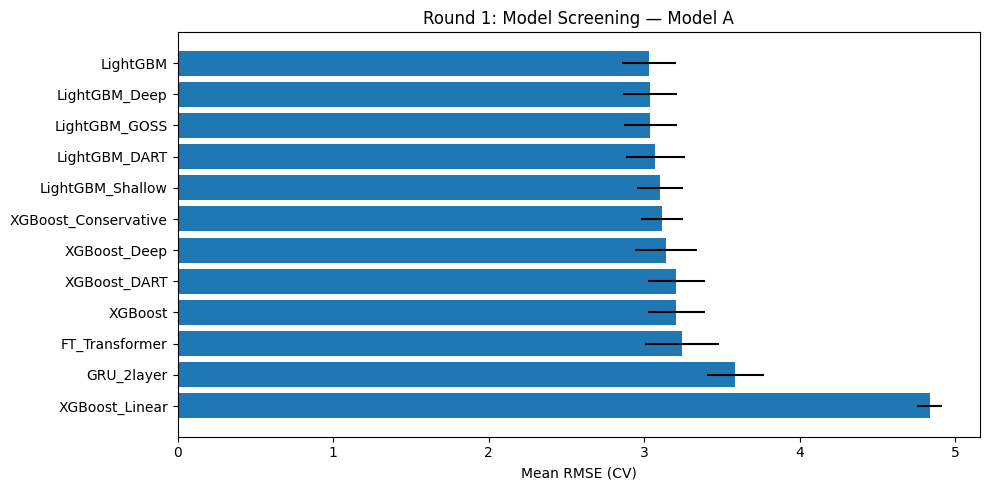

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(r1_results["model"], r1_results["mean_rmse"], xerr=r1_results["std_rmse"])
ax.set_xlabel("Mean RMSE (CV)")
ax.set_title("Round 1: Model Screening — Model A")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
top7_names = r1_results["model"].head(7).tolist()
print(f"Advancing to Round 2: {top7_names}")
eliminated = r1_results["model"].iloc[7:].tolist()
print(f"Eliminated: {eliminated}")

Advancing to Round 2: ['LightGBM', 'LightGBM_Deep', 'LightGBM_GOSS', 'LightGBM_DART', 'LightGBM_Shallow', 'XGBoost_Conservative', 'XGBoost_Deep']
Eliminated: ['XGBoost_DART', 'XGBoost', 'FT_Transformer', 'GRU_2layer', 'XGBoost_Linear']


## 4. Round 2 — Optuna HP Tuning (top 7, 10 trials each)

In [12]:
r2_results = []
for name in top7_names:
    print(f"Tuning {name}...")
    best_params, best_rmse = run_optuna_round(name, X, y, splitter, groups, n_trials=10)
    r2_results.append({"model": name, "best_rmse": best_rmse, "best_params": best_params})
    print(f"  Best RMSE: {best_rmse:.4f}")

r2_df = pd.DataFrame(r2_results).sort_values("best_rmse").reset_index(drop=True)
r2_df[["model", "best_rmse"]]

Tuning LightGBM...


  Best RMSE: 3.0055
Tuning LightGBM_Deep...


  Best RMSE: 3.0056
Tuning LightGBM_GOSS...


  Best RMSE: 2.9896
Tuning LightGBM_DART...


  Best RMSE: 2.9967
Tuning LightGBM_Shallow...


  Best RMSE: 3.0055
Tuning XGBoost_Conservative...


  Best RMSE: 3.0058
Tuning XGBoost_Deep...


  Best RMSE: 3.0058


,model,best_rmse
0,LightGBM_GOSS,2.989579
1,LightGBM_DART,2.996716
2,LightGBM_Shallow,3.005481
3,LightGBM,3.005506
4,LightGBM_Deep,3.005570
5,XGBoost_Conservative,3.005815
6,XGBoost_Deep,3.005815


In [13]:
top5_names = r2_df["model"].head(5).tolist()
r2_best_params = {row["model"]: row["best_params"] for _, row in r2_df.iterrows()}
print(f"Advancing to Round 3: {top5_names}")

Advancing to Round 3: ['LightGBM_GOSS', 'LightGBM_DART', 'LightGBM_Shallow', 'LightGBM', 'LightGBM_Deep']


## 5. Round 3 — Final HP Tuning (top 5, 15 trials each)

In [14]:
r3_results = []
for name in top5_names:
    print(f"Fine-tuning {name}...")
    best_params, best_rmse = run_optuna_round(name, X, y, splitter, groups, n_trials=15)
    r3_results.append({"model": name, "best_rmse": best_rmse, "best_params": best_params})
    print(f"  Best RMSE: {best_rmse:.4f}")

r3_df = pd.DataFrame(r3_results).sort_values("best_rmse").reset_index(drop=True)
r3_best_params = {row["model"]: row["best_params"] for _, row in r3_df.iterrows()}
r3_df[["model", "best_rmse"]]

Fine-tuning LightGBM_GOSS...


  Best RMSE: 2.9833
Fine-tuning LightGBM_DART...


  Best RMSE: 2.9862
Fine-tuning LightGBM_Shallow...


  Best RMSE: 3.0017
Fine-tuning LightGBM...


  Best RMSE: 3.0017
Fine-tuning LightGBM_Deep...


  Best RMSE: 3.0017


,model,best_rmse
0,LightGBM_GOSS,2.983261
1,LightGBM_DART,2.986246
2,LightGBM_Shallow,3.001695
3,LightGBM_Deep,3.001700
4,LightGBM,3.001719


## 6. Test Set Evaluation

In [15]:
train_idx, test_idx = splitter.get_test_split(groups)
X_train_full, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train_full, y_test = y.iloc[train_idx], y.iloc[test_idx]
id_train, id_test = df[ID_COLS].iloc[train_idx], df[ID_COLS].iloc[test_idx]

print(f"Train: {X_train_full.shape}, Test: {X_test.shape}")
print(f"Test season(s): {sorted(df['season'].iloc[test_idx].unique())}")

Train: (113177, 9), Test: (26578, 9)
Test season(s): [np.int64(2024)]


In [16]:
final_results = []
for name in top5_names:
    if name in DL_SKIP_OPTUNA:
        model_cls = MODEL_CLASSES[name]
        model = model_cls(input_dim=len(FEATURE_COLS))
    else:
        params = reconstruct_params(name, r3_best_params[name])
        model_cls = MODEL_CLASSES[name]
        model = model_cls(**params)
    model.fit(X_train_full, y_train_full)

    train_preds = model.predict(X_train_full)
    train_rmse = np.sqrt(mean_squared_error(y_train_full, train_preds))
    train_mae = mean_absolute_error(y_train_full, train_preds)

    test_preds = model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_mae = mean_absolute_error(y_test, test_preds)

    val_rmse = r3_df.loc[r3_df["model"] == name, "best_rmse"].values[0]

    final_results.append({
        "model": name,
        "train_rmse": train_rmse, "train_mae": train_mae,
        "val_rmse": val_rmse,
        "test_rmse": test_rmse, "test_mae": test_mae,
        "overfit_gap": test_rmse - val_rmse,
    })

    print(f"{name}: train_rmse={train_rmse:.4f}, val_rmse={val_rmse:.4f}, "
          f"test_rmse={test_rmse:.4f}, gap={test_rmse - val_rmse:.4f}")

final_df = pd.DataFrame(final_results).sort_values("test_rmse").reset_index(drop=True)
final_df

LightGBM_GOSS: train_rmse=2.3814, val_rmse=2.9833, test_rmse=2.7209, gap=-0.2624


LightGBM_DART: train_rmse=2.3419, val_rmse=2.9862, test_rmse=2.7731, gap=-0.2131


LightGBM_Shallow: train_rmse=2.4474, val_rmse=3.0017, test_rmse=2.7121, gap=-0.2896


LightGBM: train_rmse=2.4474, val_rmse=3.0017, test_rmse=2.7121, gap=-0.2896


LightGBM_Deep: train_rmse=2.4474, val_rmse=3.0017, test_rmse=2.7122, gap=-0.2895


,model,train_rmse,train_mae,val_rmse,test_rmse,test_mae,overfit_gap
0,LightGBM,2.447425,1.823361,3.001719,2.712108,2.016982,-0.289611
1,LightGBM_Shallow,2.447425,1.823361,3.001695,2.712119,2.016972,-0.289576
2,LightGBM_Deep,2.447425,1.823361,3.001700,2.712217,2.017056,-0.289484
3,LightGBM_GOSS,2.381387,1.771668,2.983261,2.720870,2.022851,-0.262391
4,LightGBM_DART,2.341857,1.733128,2.986246,2.773140,2.057529,-0.213106


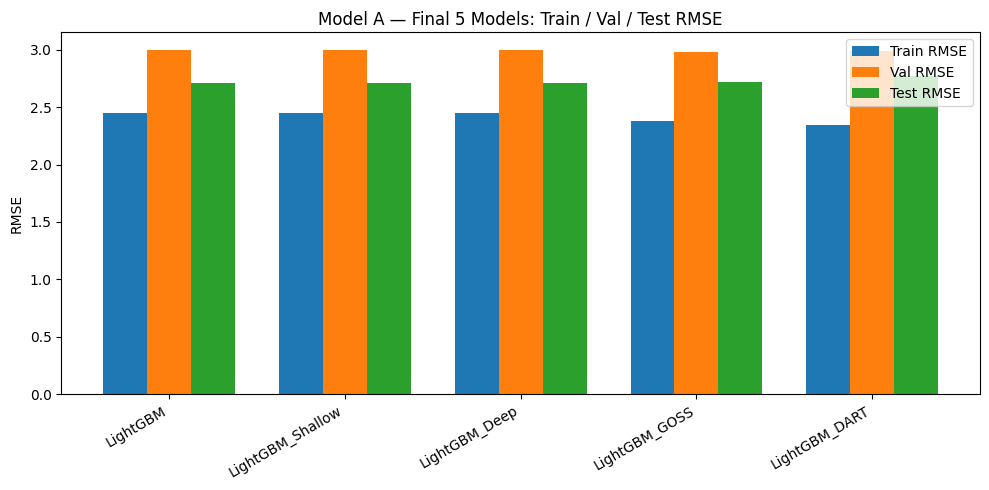

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(final_df))
w = 0.25
ax.bar(x - w, final_df["train_rmse"], w, label="Train RMSE")
ax.bar(x, final_df["val_rmse"], w, label="Val RMSE")
ax.bar(x + w, final_df["test_rmse"], w, label="Test RMSE")
ax.set_xticks(x)
ax.set_xticklabels(final_df["model"], rotation=30, ha="right")
ax.set_ylabel("RMSE")
ax.set_title("Model A — Final 5 Models: Train / Val / Test RMSE")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Save Artifacts

In [18]:
for name in top5_names:
    if name in DL_SKIP_OPTUNA:
        model_cls = MODEL_CLASSES[name]
        model = model_cls(input_dim=len(FEATURE_COLS))
    else:
        params = reconstruct_params(name, r3_best_params[name])
        model_cls = MODEL_CLASSES[name]
        model = model_cls(**params)
    model.fit(X_train_full, y_train_full)

    save_predictions(model, X_train_full, y_train_full, id_train, "A", name, "Training")
    save_predictions(model, X_test, y_test, id_test, "A", name, "Test")

    # OOF validation predictions (for Model D stacking)
    oof_preds = np.full(len(X), np.nan)
    for tr_idx, va_idx in splitter.split(groups):
        import sklearn.base
        fold_model = sklearn.base.clone(model)
        fold_model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof_preds[va_idx] = fold_model.predict(X.iloc[va_idx])

    val_mask = ~np.isnan(oof_preds)
    val_out = df[ID_COLS].loc[val_mask].copy()
    val_out["y_true"] = y.loc[val_mask].values
    val_out["y_pred"] = oof_preds[val_mask]
    fname = f"model_A_{name}_Validation.parquet"
    uri = save_training_parquet(val_out, fname, TRAINING_DIR)
    print(f"  Saved {fname} -> {uri}")

    save_model_pkl(model, "A", name)

print("\nDone! All Model A artifacts saved.")

  Saved model_A_LightGBM_GOSS_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_A_LightGBM_GOSS_Training.parquet


  Saved model_A_LightGBM_GOSS_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_A_LightGBM_GOSS_Test.parquet


  Saved model_A_LightGBM_GOSS_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_A_LightGBM_GOSS_Validation.parquet


  Saved Model_A_LightGBM_GOSS.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_A_LightGBM_GOSS.pkl


  Saved model_A_LightGBM_DART_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_A_LightGBM_DART_Training.parquet


...

  Saved Model_A_LightGBM.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_A_LightGBM.pkl


  Saved model_A_LightGBM_Deep_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_A_LightGBM_Deep_Training.parquet


  Saved model_A_LightGBM_Deep_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_A_LightGBM_Deep_Test.parquet


  Saved model_A_LightGBM_Deep_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_A_LightGBM_Deep_Validation.parquet


  Saved Model_A_LightGBM_Deep.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_A_LightGBM_Deep.pkl

Done! All Model A artifacts saved.


## Summary

In [19]:
print("=" * 60)
print("MODEL A TRAINING COMPLETE")
print("=" * 60)
print(f"\nFinal 5 models (sorted by test RMSE):")
for _, row in final_df.iterrows():
    print(f"  {row['model']:20s}  test_rmse={row['test_rmse']:.4f}  gap={row['overfit_gap']:.4f}")
print(f"\nArtifacts saved to:")
print(f"  Predictions: {TRAINING_DIR}")
print(f"  Models: {MODEL_DIR}")

MODEL A TRAINING COMPLETE

Final 5 models (sorted by test RMSE):
  LightGBM              test_rmse=2.7121  gap=-0.2896
  LightGBM_Shallow      test_rmse=2.7121  gap=-0.2896
  LightGBM_Deep         test_rmse=2.7122  gap=-0.2895
  LightGBM_GOSS         test_rmse=2.7209  gap=-0.2624
  LightGBM_DART         test_rmse=2.7731  gap=-0.2131

Artifacts saved to:
  Predictions: data/training
  Models: data/raw/model
